# 📊 Data preprocessing - Selective
**Selective preprocessing of clinical retinal fundus images.**


The purpose of this notebook is to generate different selectively preprocessed versions of the clinical retinal fundus image dataset.

Unlike the previous public dataset version, images are not loaded from class folders. Instead, this notebook reads a clinical match table where each row links an image with patient metadata, refractive data, spherical equivalent and binary myopia label.

The following preprocessing scenarios will be generated:

A. Normalization only
- With RGB conversion and normalization to [0–1].
- No geometry: no circle detection, nor padding/resizing (only dataloader resizer for 224×224 pixels).
- No CLAHE.
- No Augmentations.

B. Geometry + Normalization
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- No Augmentations.

C. Geometry + Normalization + Illumination (no Augmentantions)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- With CLAHE (luminance or blue can be chosen).
- No Augmentations.

D. Geometry + Normalization + Augmentations (no illumination)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- With geometric Augmentations: flip, light rotation and zoom applied at dataloader.

## 📚 1. Importing Libraries
Loading the necessary libraries for data analysis and images preprocessing.

In [1]:
# Some basic libraries
import os, glob, math, shutil
from pathlib import Path
from typing import Tuple, Optional, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For images preprocessing
import cv2
from PIL import Image

# For deep learning
import tensorflow as tf


In [2]:
# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


At this stage, the notebook is running on CPU only, which is fine for prototyping and testing the preprocessing pipeline. Once the pipeline is finalized, the notebook can be moved to a GPU-enabled environment (e.g., Kaggle or Google Colab) to accelerate model training.

Note: CUDA acceleration was attempted but turned out to be only available on NVIDIA GPUs. Since this Jupyter Lab environment does not provide a compatible NVIDIA GPU, all computations currently fall back to the CPU.


## 🛠️  2. Helpers preparation

To keep the codebase clean and efficient, several helper functions were implemented.  
These functions encapsulate small, reusable tasks that will be required multiple times throughout the preprocessing pipeline.


First, we declare a parameter container for further use. This way we provide the same parameters on all models

In [3]:
# Project root detection
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "0B_TFGBiomed":
    PROJECT_ROOT = PROJECT_ROOT.parent

IMAGES_DIR = PROJECT_ROOT / "Images"
TABLES_DIR = PROJECT_ROOT / "Tables"
SPLITS_DIR = PROJECT_ROOT / "Splits"
MODELS_DIR = PROJECT_ROOT / "Models"

for folder in [IMAGES_DIR, TABLES_DIR, SPLITS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

In [4]:
class CFG:
    #Paths for inputs   
    INPUT_TABLE = TABLES_DIR / "MatchTables" / "Tabla_MatchImagenesConDatosClinicos.xlsx" # Input clinical match table
    INPUT_IMAGE_DIR = IMAGES_DIR / "00_OG_GaldosPictures" #Carpeta donde están las imágenes ORIGINALES 

    # Output root for selective preprocessing scenarios
    OUTPUT_ROOT = IMAGES_DIR / "02_SelectivePreprocessing_GaldosPictures"

    # Scenario-specific output folders
    OUTPUT_DIR_A = OUTPUT_ROOT / "A_Raw_minimal"
    OUTPUT_DIR_B = OUTPUT_ROOT / "B_GeoNorm"
    OUTPUT_DIR_C = OUTPUT_ROOT / "C_GeoNorm_Illum_NoAug"

    # Scenario-specific output tables
    OUTPUT_TABLE_A = TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.A.xlsx"
    OUTPUT_TABLE_B = TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx"
    OUTPUT_TABLE_C = TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.C.xlsx"

    #Geometry and size
    IMAGE_SIZE = 224                  # final square size (e.g., 224 tamaño og, 256 tamaño habitual ImageNet, 299)
    DETECT_FUNDUS  = True             # circle detection + circular crop
    PAD_AND_RESIZE = True             # pad to square + resize to IMAGE_SIZE

    #Illumination/enhancement
    APPLY_CLAHE = True                # cCntrast Limited Adaptive Histogram Equalization
    CLAHE_MODE = "luminance"          # choosing CLAHE channel from "luminance" | "green" | "blue" | "none"

    #Normalization
    NORMALIZATION = "0-1"             # "0-1" | "zscore" | "imagenet"

    #I/O
    OUTPUT_EXT = ".jpg"
    JPG_QUALITY = 95
    VERBOSE = True                    # gives messages while preprocessing for visual progress

    # Train-time only (used later in the models notebook, right?)
    AUGMENT = False          # data augmentations in the dataloader (not applied here)

CFG.INPUT_TABLE.parent.mkdir(parents=True, exist_ok=True)
CFG.OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
assert CFG.INPUT_TABLE.exists(), f"Missing input table: {CFG.INPUT_TABLE}"
assert CFG.INPUT_IMAGE_DIR.exists(), f"Missing input image folder: {CFG.INPUT_IMAGE_DIR}"

# Reproducibility: setting set split, weights and training on same random parameter making it easier to compare modelss
np.random.seed(42)

#### 2.1 Loading the clinical match table

The match table is loaded from Excel and linked again to the original image folder using the filename column.

This is important because the `image_path` column may point to a previously preprocessed image folder. For preprocessing notebooks, the input must always be the original image folder.

In [5]:
def rebuild_input_paths_from_filename(df: pd.DataFrame, input_dir: Path) -> pd.DataFrame:
    #Rebuilds image paths using the filename column and the original image directory

    input_dir = Path(input_dir)

    filename_to_path = {
        p.name: str(p.resolve())
        for p in list(input_dir.rglob("*.jpg")) +
                 list(input_dir.rglob("*.jpeg")) +
                 list(input_dir.rglob("*.png"))
    }

    df = df.copy()
    df["image_path"] = df["filename"].map(filename_to_path)

    missing = df["image_path"].isna().sum()

    print("Images found:", df["image_path"].notna().sum())
    print("Images missing:", missing)

    if missing > 0:
        print("Examples missing:")
        print(df[df["image_path"].isna()]["filename"].head(10).tolist())

    return df

In [6]:
df = pd.read_excel(CFG.INPUT_TABLE)

df = rebuild_input_paths_from_filename(df, CFG.INPUT_IMAGE_DIR)

# Keep only rows with valid image paths and valid targets
df = df[df["image_path"].notna()].copy()
df = df[df["filename"].notna()].copy()
df = df[df["target_SE"].notna()].copy()
df = df[df["class_label"].notna()].copy()

df["image_path"] = df["image_path"].astype(str)
df["filename"] = df["filename"].astype(str)
df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")
df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("Int64")

df = df.dropna(
    subset=["image_path", "filename", "patient_id", "target_SE", "class_label"]
).copy()

print("Total valid rows:", len(df))

print("\nClassification label balance:")
print(df["class_label"].value_counts())

print("\nTarget SE summary:")
print(df["target_SE"].describe())

print("\nModality distribution:")
print(df["modality"].value_counts())

print("\nEye distribution:")
print(df["eye"].value_counts())

df.head()

Images found: 2346
Images missing: 0
Total valid rows: 2126

Classification label balance:
class_label
0    1645
1     481
Name: count, dtype: Int64

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64

Modality distribution:
modality
Color    1960
IR        166
Name: count, dtype: int64

Eye distribution:
eye
L    1070
R    1056
Name: count, dtype: int64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,OI_ESF,OI_CIL,OI_EJE,EquivalenteEsférico_Derecho,EquivalenteEsférico_Izquierdo,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label
0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6.0,...,0.00,0.00,0.0,0.00,0.000,SI,2024-09-17,id+date,0.000,0
1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6.0,...,0.00,0.00,0.0,0.00,0.000,SI,2024-09-17,id+date,0.000,0
2,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51.0,...,-0.25,-0.75,180.0,-2.25,-0.625,NO,2023-12-11,id+date,-2.250,1
3,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51.0,...,-0.25,-0.75,180.0,-2.25,-0.625,NO,2023-12-11,id+date,-0.625,1
4,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26.0,...,-0.25,0.00,0.0,0.00,-0.250,NO,2023-04-12,id+date,0.000,0


#### 🖼️  2.2 Image I/O
Reading images in BGR format (`read_image_bgr`), and converting them to RGB (`bgr_to_rgb`).

We are reading images into BGR format because the tool used for it (OpenCV) reads them into this format. Then, we transform BGR pics into RGB format so as to make them compatible with deep learning libraries (TensorFlow).

In [7]:
def read_image_bgr(path: str) -> np.ndarray:
    #Reads image with cv2 (Pyhton module for OpenCV, faster than keras o tensorflow) in BGR space (RBG in different order for cv2)
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Failed to read image: {path}")
    return img #returns np.uint8 array

def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    #Necessary conversion bc OpenCV works on BGR but deep learning libraries expect RGB
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def rgb_to_bgr(img_rgb: np.ndarray) -> np.ndarray: #Converts RGB image back to BGR for OpenCV saving.
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)


#### 📂  2.3 File management
Creating directories when needed (`ensure_dir`).

In [8]:
def ensure_dir(path):
    #Creates directory if does not yet exist
    os.makedirs(path, exist_ok=True)

#### 📐  2.4 Geometry operations - Square
Padding an image to a square shape without distortion (`center_pad_to_square`).

In [9]:
def center_pad_to_square(img: np.ndarray, value: int = 0) -> np.ndarray:
    #Calculates how much space the image needs to become square. Pads images with square black shape around the center (without distorting the eye)
    h, w = img.shape[:2]
    side = max(h, w)
    top = (side - h) // 2 #divides by 2 and saves integer into top (redondeo hacia abajo)
    bottom = side - h - top
    left = (side - w) // 2
    right = side - w - left
    return cv2.copyMakeBorder(img, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=[value, value, value])

#### 🎯  2.5 Geometry operations - Circular ROI and padding
Circular ROI (Region Of Interest) detection helpers: tries Hough first, if it fails it falls back to largest contour, if both fail it keeps the original image (but still pads & resizes).

- Hough is a classic algorithm that tries finding circles on image based on margins and gradients of a grayscale.
- Largest contour in OpenCV is a curve that follows the borders of a detected region trough converting it into B&W.

Then, the ROI is padded in black.

In [10]:
def detect_fundus_circle(img_bgr: np.ndarray) -> Optional[Tuple[int, int, int]]:
    # Tries to detect the circular fundus (gives back center x, y and radius r of circle)
    # It first tries Hough and if not, Fallback
    
    # Grayscale to simplify calculations (no color means less noise)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 7) # even less noise with median filter

    # A) Uses HoughCircles on the blurred grayscale
    # Tries finding circles on image based on margins and gradients
    circles = cv2.HoughCircles(
        gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=min(gray.shape)//2, #dp resolution, minDist between circles so they are not too close
        param1=60, param2=30, minRadius=min(gray.shape)//6, maxRadius=min(gray.shape)//1 #radius sizes for expected circles
    )
    if circles is not None and len(circles) > 0:
        circles = np.uint16(np.around(circles[0]))
        # Pick the largest circle (safer in clutter)
        cx, cy, r = max(circles, key=lambda c: c[2])
        return int(cx), int(cy), int(r) # Returns (cx, cy, r) in pixel coords, or None if not found.

    # B) Fallback: if Hough does not find circles then threshold + largest contour -> minEnclosingCircle
    # Adaptive threshold to separate bright disc from background
    thr = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY, 51, 2)
    # Keep largest bright component on image (will be the whole fundus)
    contours, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        (x, y), r = cv2.minEnclosingCircle(cnt)
        return int(x), int(y), int(r)

    return None

def circular_crop(img_bgr: np.ndarray, circle: Tuple[int,int,int]) -> np.ndarray:
    # Crops the circular ROI and creates black background outside
    h, w = img_bgr.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8) #black mask for backgorund
    cx, cy, r = circle
    cv2.circle(mask, (cx, cy), r, 255, -1) # 0-255 grayscale for mask, -1 is circle thickness (cv2 gets whole circle this way)
    fg = cv2.bitwise_and(img_bgr, img_bgr, mask=mask) # Apply mask
    # Bounding square around the circle and deleting rest:
    x1, y1 = max(cx - r, 0), max(cy - r, 0)
    x2, y2 = min(cx + r, w), min(cy + r, h)
    cropped = fg[y1:y2, x1:x2]
    return cropped

#### ✨  2.6 Enhancement
Applying CLAHE for local contrast improvement (`apply_clahe`).

CLAHE (Contrast Limited Adaptive Histogram Equalization) is an image processing technique that:  
- Enhances the local (little groups of pixels) contrast of an image.  
- Prevents overly bright regions from becoming saturated (contrast limited).  
- Is especially useful in medical imaging (e.g., retinal fundus photographs), as it highlights details such as blood vessels and the optic disc.  

Note:
By default, CLAHE is applied on the luminance channel (LAB-L), which usually improves retinal contrast without introducing color artifacts.  
Since this dataset contains blue fundus images, we can also experiment with `CLAHE_MODE="blue"` and compare results.


In [11]:
def apply_clahe(img_bgr: np.ndarray, mode: str = "luminance") -> np.ndarray:
    if mode == "none": #no changes to og image
        return img_bgr

    if mode == "luminance": #convert to LAB (Lightness/Green-Red/Blue-Yellow), apply CLAHE on L (Luminance) channel
        #LAB separates luminance from color so we can change light only and not colors - very useful in medicine
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) #contrast limit and grid splitting for CLAHE on each block
        l2 = clahe.apply(l)
        lab2 = cv2.merge([l2, a, b])
        return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

    b, g, r = cv2.split(img_bgr)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    #chooses which color channel applies CLAHE to 
    if mode == "green": #apply CLAHE on green channel only (good for blood vessels)
        g = clahe.apply(g)
    elif mode == "blue": #apply CLAHE on blue channel only
        b = clahe.apply(b)
    else:
        return img_bgr
        
    return cv2.merge([b, g, r])

#### ⚖️  2.7 Normalization
Scaling pixel values into a consistent range (e.g., [0–1], z-score, or ImageNet mean/std) to stabilize training and ensure compatibility with deep learning models.

In [12]:
# Mean and standard deviation values of each RGB channel, calculated on ImageNet dataset (we use the same for standardization)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def normalize(img_rgb: np.ndarray, mode: str = "0-1") -> np.ndarray:
    # Normalize image to float32 (decimals necessary on deep learning since we'll normalize values 0-1)
    x = img_rgb.astype(np.float32)

    if mode == "0-1": #scale to [0,1] (for models from scratch)
        x /= 255.0
        return x

    if mode == "zscore": #per-image (x - mean) / std (can help if illuminaion varies a lot accross images)
        x /= 255.0
        m = x.mean(axis=(0,1), keepdims=True)
        s = x.std(axis=(0,1), keepdims=True) + 1e-6
        return (x - m) / s

    if mode == "imagenet": #(x/255 - mean) / std (for transfer learning pretrained backbones)
        x /= 255.0
        return (x - IMAGENET_MEAN) / IMAGENET_STD

    # default just in case
    x /= 255.0
    return x #returns float32 RGB image

def to_uint8_for_saving(img_rgb_float: np.ndarray, normalization: str = "0-1") -> np.ndarray: #Converts a normalized float image back to uint8 format for saving.
    x = img_rgb_float.copy()

    if normalization == "0-1":
        x = x * 255.0
    elif normalization == "zscore":
        x = (x - x.min()) / (x.max() - x.min() + 1e-6)
        x = x * 255.0
    elif normalization == "imagenet":
        x = (x * IMAGENET_STD + IMAGENET_MEAN) * 255.0
        
    x = np.clip(x, 0, 255).astype(np.uint8)
    return x

#### 🧩  2.8 Preprocessing pipeline for single image

The function `preprocess_image()` applies the full preprocessing pipeline to a single fundus image using the parameters defined in `CFG`.  

Steps:
1. Circle detection & cropping: localizes the retinal fundus and removes irrelevant background.  
2. Square padding & resizing: pads the image to preserve aspect ratio, then resizes to `CFG.IMAGE_SIZE`.  
3. Contrast enhancement (optional): applies CLAHE depending on `CFG.APPLY_CLAHE` and `CFG.CLAHE_MODE`.  
4. Color conversion & normalization: converts BGR→RGB and normalizes pixel values according to `CFG.NORMALIZATION`.  

Output: a `float32` RGB image of shape `(IMAGE_SIZE, IMAGE_SIZE, 3)`, normalized and ready for model input.


In [13]:
def preprocess_image(path: str, cfg: CFG = CFG) -> np.ndarray: #preprocessing pipeline of 1 image with class CFG params
    img_bgr = read_image_bgr(path)

    # 1) Detect circle & crop
    if cfg.DETECT_FUNDUS:
        circle = detect_fundus_circle(img_bgr)
        if circle is not None:
            img_bgr = circular_crop(img_bgr, circle)
    # if fundus not detected: leave as is (some datasets will already be centered)

    # 2) Pad to square (keeps circle centered), then resize
    if cfg.PAD_AND_RESIZE:
        img_bgr = center_pad_to_square(img_bgr, value=0)
        img_bgr = cv2.resize(img_bgr, (cfg.IMAGE_SIZE, cfg.IMAGE_SIZE),
                             interpolation=cv2.INTER_AREA)

    # 3) CLAHE 
    if cfg.APPLY_CLAHE and cfg.CLAHE_MODE != "none":
        img_bgr = apply_clahe(img_bgr, mode=cfg.CLAHE_MODE)

    # 4) Convert to RGB and normalize
    img_rgb = bgr_to_rgb(img_bgr)
    img_rgb = normalize(img_rgb, mode=cfg.NORMALIZATION)

    return img_rgb #returns float32 RGB image of shape (IMAGE_SIZE, IMAGE_SIZE, 3) 

#### 👀  2.9 Preview utilities

Allows for gridview and makes sure all images are preprocessed, comparing number to OG folder.

In [14]:
def show_grid(images: List[np.ndarray], titles: Optional[List[str]] = None, cols: int = 4, suptitle: str = ""): #to see pics in grid
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=(3*cols, 3*rows))
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i+1)
        # assume RGB float or uint8
        if img.dtype != np.uint8 and img.max() <= 1.0:
            plt.imshow(img)
        else:
            plt.imshow(img.astype(np.uint8))
        plt.axis('off')
        if titles:
            plt.title(titles[i], fontsize=9)
    if suptitle:
        plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

def preview_samples(df: pd.DataFrame, cfg: CFG = CFG, k: int = 8): #Shows a preview of k selectively preprocessed images.
    sample_df = df.sample(min(k, len(df)), random_state=42)
    imgs = []
    titles = []

    for _, row in sample_df.iterrows():
        try:
            img = preprocess_image(row["image_path"], cfg)
            imgs.append(img)
            titles.append(row["filename"])
        except Exception as e:
            print("Preview error:", row["image_path"], e)

    show_grid(imgs, titles=titles, cols=4, suptitle="Selective preprocessing preview")

#### 📦  2.10 Batch export:
Saving all our preprocessed pics correctly

In [15]:
def export_preprocessed_dataset(df: pd.DataFrame, cfg: CFG = CFG, limit: Optional[int] = None) -> pd.DataFrame:
    # Puts preprocessed images from INPUT_DIR/<class>/* as PNG to OUTPUT_DIR/<class>/ (keeps subfolder structure)

    output_dir = Path(cfg.OUTPUT_DIR)
    
    # Clear output path (safe approach while iterating, deletes old folder and substitutes with new one with new pics)
    if output_dir.exists():
        shutil.rmtree(output_dir)
    ensure_dir(output_dir)
    
    work_df = df.copy()
    if limit is not None:
        work_df = work_df.head(limit).copy()
    new_paths = []
    failed_rows = []

    for idx, row in work_df.iterrows():
        src_path = row["image_path"]
        filename = Path(row["filename"]).stem + cfg.OUTPUT_EXT
        dst_path = output_dir / filename

        try:
            img = preprocess_image(src_path, cfg)

            img_uint8 = to_uint8_for_saving(
                img,
                normalization=cfg.NORMALIZATION
            )

            cv2.imwrite(
                str(dst_path),
                rgb_to_bgr(img_uint8),
                [cv2.IMWRITE_JPEG_QUALITY, cfg.JPG_QUALITY]
            )

            new_paths.append(str(dst_path.resolve()))

        except Exception as e:
            print(f"Failed: {src_path} -> {e}")
            new_paths.append(pd.NA)
            failed_rows.append(idx)

    work_df["original_image_path"] = work_df["image_path"]
    work_df["image_path"] = new_paths

    work_df["preprocessing"] = Path(cfg.OUTPUT_DIR).name
    work_df["image_size"] = cfg.IMAGE_SIZE
    work_df["detect_fundus"] = cfg.DETECT_FUNDUS
    work_df["pad_and_resize"] = cfg.PAD_AND_RESIZE
    work_df["clahe_applied"] = cfg.APPLY_CLAHE
    work_df["clahe_mode"] = cfg.CLAHE_MODE

    work_df = work_df[work_df["image_path"].notna()].copy()

    print("Export finished.")
    print("Successful images:", len(work_df))
    print("Failed images:", len(failed_rows))
    print("Output folder:", output_dir)

    return work_df

#### ✅  2.11 Sanity check:
Running a test before introducing all the pcitures

In [16]:
def count_images_in_dir(path: Path): # Counts image files inside a directory.
    image_extensions = {".jpg", ".jpeg", ".png"}

    files = [
        p for p in Path(path).rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    ]

    return len(files)


def verify_export(df_exported: pd.DataFrame, output_dir: Path): # Verifies that exported images and table paths are consistent.
    n_exported = count_images_in_dir(output_dir)
    print("Images in output directory:", n_exported)
    print("Rows in updated table:", len(df_exported))

    if len(df_exported) == 0:
        print("Warning: no images were exported. Please review input paths.")
        return

    missing_paths = df_exported["image_path"].apply(lambda p: not Path(p).exists()).sum()
    print("Missing paths in updated table:", missing_paths)

    if n_exported == len(df_exported) and missing_paths == 0:
        print("Ready! All exported images are correctly linked in the updated table.")
    else:
        print("Warning: mismatch detected. Please review exported files and table paths.")

## 🗂️ 3. Preprocessing the Dataset
Finally getting to the preprocessing. The data is loaded from a folder in the workspace, and we are choosing which type of preprocessing we are applying on each picture.

#### 🇦 3.1 Raw images
Firstly, using the raw images with mere normalization and disregarding corrupt pictures.

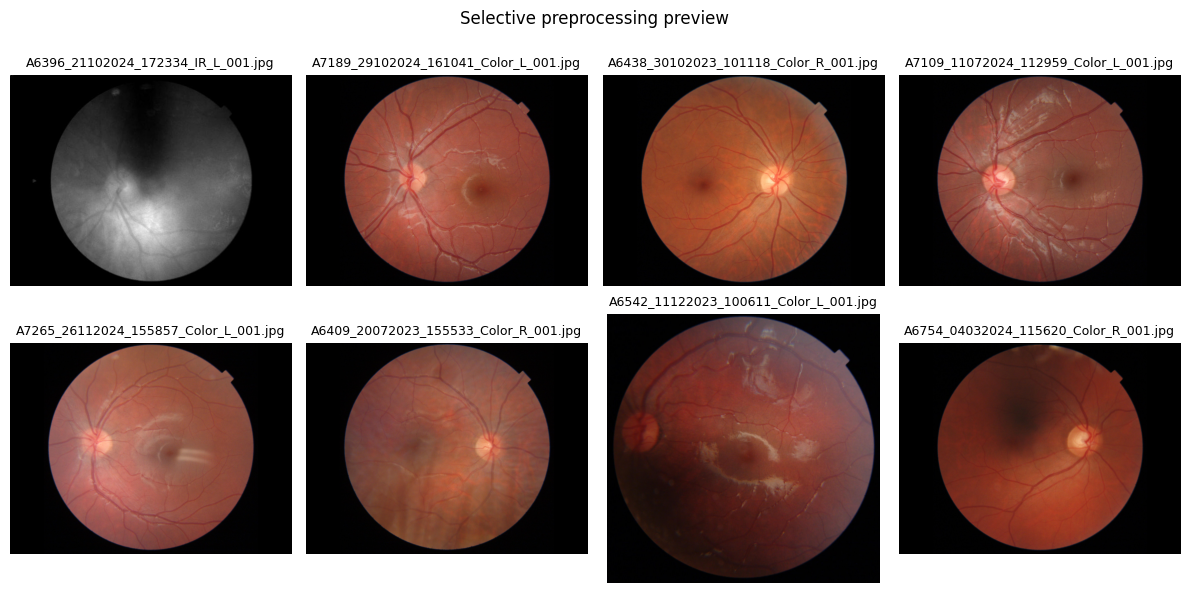

Export finished.
Successful images: 2126
Failed images: 0
Output folder: C:\Users\paula\0B_TFGBiomed\Images\02_SelectivePreprocessing_GaldosPictures\A_Raw_minimal
Updated match table saved at: C:\Users\paula\0B_TFGBiomed\Tables\MatchTables\TablaMatch_SCENARIO.A.xlsx
Images in output directory: 2126
Rows in updated table: 2126
Missing paths in updated table: 0
Ready! All exported images are correctly linked in the updated table.


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51.0,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51.0,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none


In [17]:
#Setting CFG up:
CFG.DETECT_FUNDUS=False
CFG.PAD_AND_RESIZE=False
CFG.APPLY_CLAHE=False
CFG.CLAHE_MODE = "none"

CFG.OUTPUT_DIR = CFG.OUTPUT_DIR_A # output path for preprocessed images - depending on level of preprocessing
CFG.OUTPUT_TABLE = CFG.OUTPUT_TABLE_A # (changes with each scenario)

preview_samples(df, CFG, k=8)

# Batch-export the whole set
df_A = export_preprocessed_dataset(df, CFG, limit=None)
df_A.to_excel(CFG.OUTPUT_TABLE, index=False)

print("Updated match table saved at:", CFG.OUTPUT_TABLE)
      
# Dataset counts
verify_export(df_A, CFG.OUTPUT_DIR)

df_A.head()

#### 🇧 3.2 No Illumination and no Augmentations
This time only geometry and normalization preprocessing are applied.

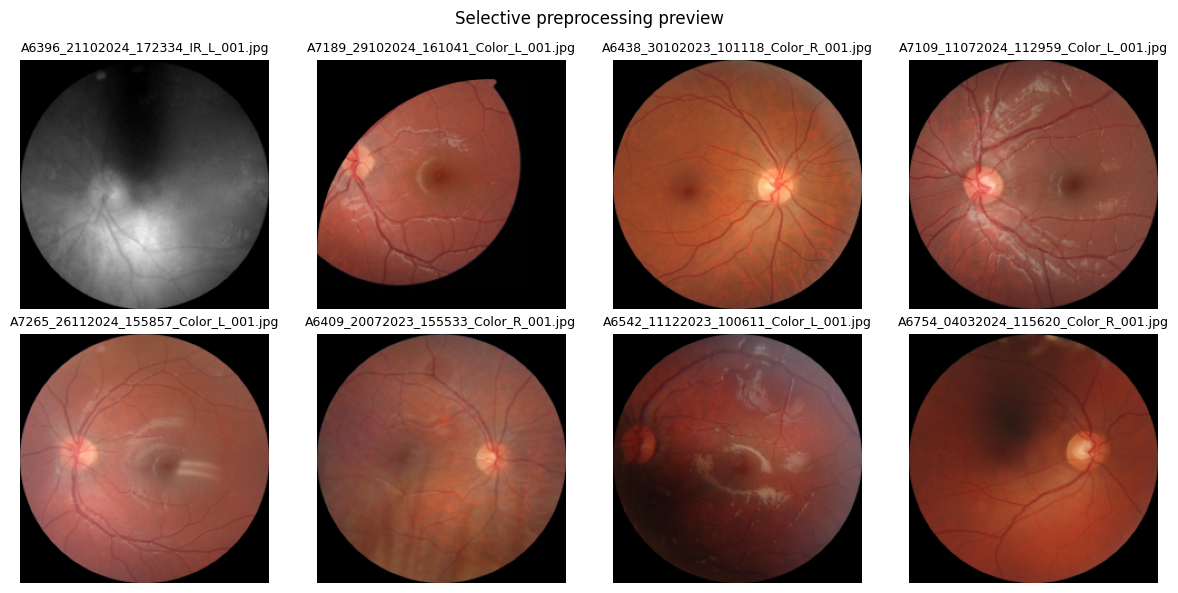

Export finished.
Successful images: 2126
Failed images: 0
Output folder: C:\Users\paula\0B_TFGBiomed\Images\02_SelectivePreprocessing_GaldosPictures\B_GeoNorm
Updated match table saved at: C:\Users\paula\0B_TFGBiomed\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx
Images in output directory: 2126
Rows in updated table: 2126
Missing paths in updated table: 0
Ready! All exported images are correctly linked in the updated table.


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,B_GeoNorm,224,True,True,False,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,B_GeoNorm,224,True,True,False,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51.0,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,B_GeoNorm,224,True,True,False,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51.0,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,B_GeoNorm,224,True,True,False,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,B_GeoNorm,224,True,True,False,none


In [18]:
#Setting CFG up:
CFG.DETECT_FUNDUS=True
CFG.PAD_AND_RESIZE=True
CFG.APPLY_CLAHE=False
CFG.CLAHE_MODE = "none"

CFG.OUTPUT_DIR = CFG.OUTPUT_DIR_B # output path for preprocessed images - depending on level of preprocessing
CFG.OUTPUT_TABLE = CFG.OUTPUT_TABLE_B # (changes with each scenario)

preview_samples(df, CFG, k=8)

# Batch-export the whole set
df_B = export_preprocessed_dataset(df, CFG, limit=None)
df_B.to_excel(CFG.OUTPUT_TABLE, index=False)

print("Updated match table saved at:", CFG.OUTPUT_TABLE)
      
# Dataset counts
verify_export(df_B, CFG.OUTPUT_DIR)

df_B.head()

#### 🇨 3.3 With Illumination (no augmentations)
This time only geometry, normalization and illumination preprocessing are applied.

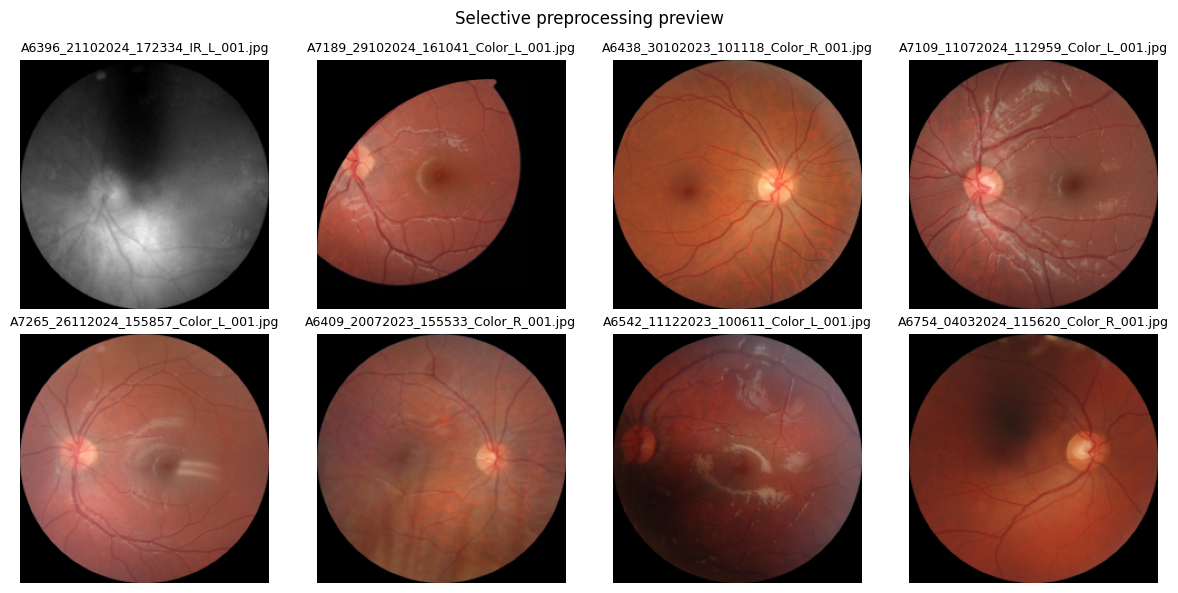

Export finished.
Successful images: 2126
Failed images: 0
Output folder: C:\Users\paula\0B_TFGBiomed\Images\02_SelectivePreprocessing_GaldosPictures\C_GeoNorm_Illum_NoAug
Updated match table saved at: C:\Users\paula\0B_TFGBiomed\Tables\MatchTables\TablaMatch_SCENARIO.C.xlsx
Images in output directory: 2126
Rows in updated table: 2126
Missing paths in updated table: 0
Ready! All exported images are correctly linked in the updated table.


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,C_GeoNorm_Illum_NoAug,224,True,True,True,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,C_GeoNorm_Illum_NoAug,224,True,True,True,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51.0,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,C_GeoNorm_Illum_NoAug,224,True,True,True,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51.0,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,C_GeoNorm_Illum_NoAug,224,True,True,True,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26.0,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,C_GeoNorm_Illum_NoAug,224,True,True,True,none


In [19]:
#Setting CFG up:
CFG.DETECT_FUNDUS=True
CFG.PAD_AND_RESIZE=True
CFG.APPLY_CLAHE=True

CFG.OUTPUT_DIR = CFG.OUTPUT_DIR_C # output path for preprocessed images - depending on level of preprocessing
CFG.OUTPUT_TABLE = CFG.OUTPUT_TABLE_C # (changes with each scenario)

preview_samples(df, CFG, k=8)

# Batch-export the whole set
df_C = export_preprocessed_dataset(df, CFG, limit=None)
df_C.to_excel(CFG.OUTPUT_TABLE, index=False)

print("Updated match table saved at:", CFG.OUTPUT_TABLE)
      
# Dataset counts
verify_export(df_C, CFG.OUTPUT_DIR)

df_C.head()

#### 🇩 3.4 With Augmentations (no illumination)
This time only geometry, normalization and augmentations are applied.

In [20]:
CFG.OUTPUT_DIR = CFG.OUTPUT_TABLE_B
# In this case the data export does not affect our model. We'll apply augmentations on the models notebook directly using Scenario B of preprocessing (geometry and normalization + augms in models notebook)

Ready! All sets of images have been properly preprocessed :)

## 4. Final selective preprocessing summary

The following tables were generated:

- `TablaMatch_A_Raw_minimal.xlsx`
- `TablaMatch_B_GeoNorm.xlsx`
- `TablaMatch_C_GeoNorm_Illum_NoAug.xlsx`

Scenario D will reuse:

- `TablaMatch_B_GeoNorm.xlsx`

and will apply training-time augmentations in the model notebook.

In [21]:
summary_selective_preprocessing = pd.DataFrame([
    {
        "scenario": "A_Raw_minimal",
        "table": str(CFG.OUTPUT_TABLE_A),
        "image_folder": str(CFG.OUTPUT_DIR_A),
        "detect_fundus": False,
        "pad_and_resize": False,
        "clahe": False,
        "augmentation_in_model": False,
        "n_images": len(df_A)
    },
    {
        "scenario": "B_GeoNorm",
        "table": str(CFG.OUTPUT_TABLE_B),
        "image_folder": str(CFG.OUTPUT_DIR_B),
        "detect_fundus": True,
        "pad_and_resize": True,
        "clahe": False,
        "augmentation_in_model": False,
        "n_images": len(df_B)
    },
    {
        "scenario": "C_GeoNorm_Illum_NoAug",
        "table": str(CFG.OUTPUT_TABLE_C),
        "image_folder": str(CFG.OUTPUT_DIR_C),
        "detect_fundus": True,
        "pad_and_resize": True,
        "clahe": True,
        "augmentation_in_model": False,
        "n_images": len(df_C)
    },
    {
        "scenario": "D_GeoNorm_Aug_NoIllum",
        "table": str(CFG.OUTPUT_TABLE_B),
        "image_folder": str(CFG.OUTPUT_DIR_B),
        "detect_fundus": True,
        "pad_and_resize": True,
        "clahe": False,
        "augmentation_in_model": True,
        "n_images": len(df_B)
    }
])

summary_selective_preprocessing

,scenario,table,image_folder,detect_fundus,pad_and_resize,clahe,augmentation_in_model,n_images
0,A_Raw_minimal,C:\Users\paula\0B_TFGBiomed\Tables\MatchTables...,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,False,False,False,False,2126
1,B_GeoNorm,C:\Users\paula\0B_TFGBiomed\Tables\MatchTables...,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,True,True,False,False,2126
2,C_GeoNorm_Illum_NoAug,C:\Users\paula\0B_TFGBiomed\Tables\MatchTables...,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,True,True,True,False,2126
3,D_GeoNorm_Aug_NoIllum,C:\Users\paula\0B_TFGBiomed\Tables\MatchTables...,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,True,True,False,True,2126
